Isabella Esquivel
April 14, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146


##Heart Failure: Predictors of Ejection Fraction

###Non-linear Modeling



# 1. Introduction


#### Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators relate is essential to quantifying the risk of death following heart failure and to improve disease management.

##### Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

##### Relevant Previous Analysis Results

Linear regression findings suggest that both physiological factors (`serum sodium`) and demographic characteristics (`sex`) may play a role in explaining variation in cardiac function (`ejection_fraction`) within this heart failure population.

Four classification techniques were evaluated to predict the event of death using a held-out test set of 299 patients. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only `ejection fraction` and `serum creatinine,` test accuracy improved to approximately 85.9%.

#### Study Objective

The objective of this study is to evaluate whether nonlinear modeling techniques provide meaningful improvements over linear models in predicting and explaining variation in `ejection fraction`.

Specifically, this study compares multiple approaches for analyzing potential nonlinearity, including `polynomial regression`, `step functions`, `regression splines`, `smoothing splines`, `local regression (LOESS)`, and `generalized additive models (GAMs)`. These methods are used to determine whether increased model flexibility leads to improved fit or shows nonlinear patterns.

Additionally, a classification framework is applied by modeling the probability of low `ejection fraction` (below 30).

The goal is to determine whether the relationship between predictors, such as `serum sodium,` `age`, and `sex `and heart function `ejection fraction` is truly nonlinear, or whether simpler linear models are sufficient.

# 2. Data and Methods

 ### Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

Table 1

In [ ]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

Summary of each clinical and demographic factor in the Heart Failure Dataset:

In [ ]:
summary(HeartFailure)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

In [ ]:
install.packages('ISLR2')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ISLR2)
attach(Wage)

In [ ]:
HeartFailure <- read.csv("HeartFailure.csv")

In [ ]:
head(HeartFailure)
names(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


[1] "age"                      "anaemia"                 
 [3] "creatinine_phosphokinase" "diabetes"                
 [5] "ejection_fraction"        "high_blood_pressure"     
 [7] "platelets"                "serum_creatinine"        
 [9] "serum_sodium"             "sex"                     
[11] "smoking"                  "time"                    
[13] "DEATH_EVENT"

# 3. Model

## Polynomial Regression and Step Functions

To examine whether the relationship between `serum sodium` and `ejection fraction` is nonlinear, a fourth-degree polynomial regression model was fitted. This approach allows for curvature in the relationship instead of assuming a straight-line effect.

#### Orthogonal Polynomial

In [ ]:
fit <- lm(ejection_fraction ~ poly(serum_sodium, 4), data = HeartFailure)
coef(summary(fit))

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),38.0836120,0.6772409,56.23348053,2.288283e-159
"poly(serum_sodium, 4)1",35.9370169,11.7105896,3.06876238,2.349929e-03
"poly(serum_sodium, 4)2",6.7306780,11.7105896,0.57475142,5.658990e-01
"poly(serum_sodium, 4)3",-0.1245382,11.7105896,-0.01063467,9.915221e-01
"poly(serum_sodium, 4)4",9.1420841,11.7105896,0.78066813,4.356258e-01


The results show that only the first polynomial term is statistically significant `(p ≈ 0.0023)`, while higher-order terms `(p-values of 0.565, 0.991, and 0.436)` are not. This may mean that additional complexity does not improve the model, demonstrating that the relationship between `serum sodium `and `ejection fraction` is largely linear. These findings are consistent with the results from previous analysis.

#### Raw Polynomial


Using raw polynomial terms instead of orthogonal polynomials produces different coefficient estimates, but does not change the overall model fit or conclusions, as none of the higher-order terms are statistically significant.

In [ ]:
fit2 <- lm(ejection_fraction ~ poly(serum_sodium, 4, raw = T), data = HeartFailure)
coef(summary(fit2))

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),4.523936e+04,5.784172e+04,0.7821234,0.4347715
"poly(serum_sodium, 4, raw = T)1",-1.382990e+03,1.769894e+03,-0.7813968,0.4351979
"poly(serum_sodium, 4, raw = T)2",1.582675e+01,2.026314e+01,0.7810608,0.4353952
"poly(serum_sodium, 4, raw = T)3",-8.032728e-02,1.028862e-01,-0.7807389,0.4355843
"poly(serum_sodium, 4, raw = T)4",1.526247e-04,1.955053e-04,0.7806681,0.4356258


The fitted values from the orthogonal and raw polynomial models are identical, as shown by the perfect linear relationship in the plot.

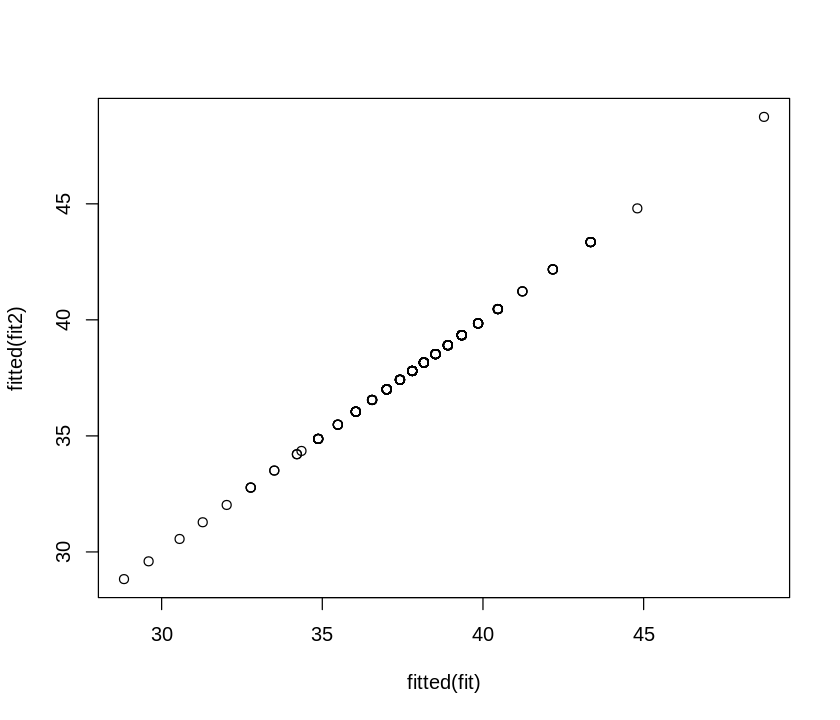

In [ ]:
plot(fitted(fit),fitted(fit2))

#### Manually Including Powers of Serum Sodium: Polynomial

The polynomial model can also be specified by manually including powers of serum sodium using the `I()` function. The resulting fitted values are identical to those obtained using the `poly()` function, as shown by the perfect linear relationship between predictions.

The fitted polynomial model using raw terms is:

$$EF = 45239 - 1382x + 15.83x^2 - 0.0803x^3 + 0.0001526x^4$$

where $x$ represents serum sodium. The coefficient values appear large and differ from the orthogonal polynomial representation.

In [ ]:
fit2a <- lm(ejection_fraction ~ serum_sodium + I(serum_sodium^2) + I(serum_sodium^3) + I(serum_sodium^4),
    data = HeartFailure)
coef(fit2a)

(Intercept)      serum_sodium I(serum_sodium^2) I(serum_sodium^3) 
     4.523936e+04     -1.382990e+03      1.582675e+01     -8.032728e-02 
I(serum_sodium^4) 
     1.526247e-04

However, this confirms that different formulations of the polynomial model yield the same results:

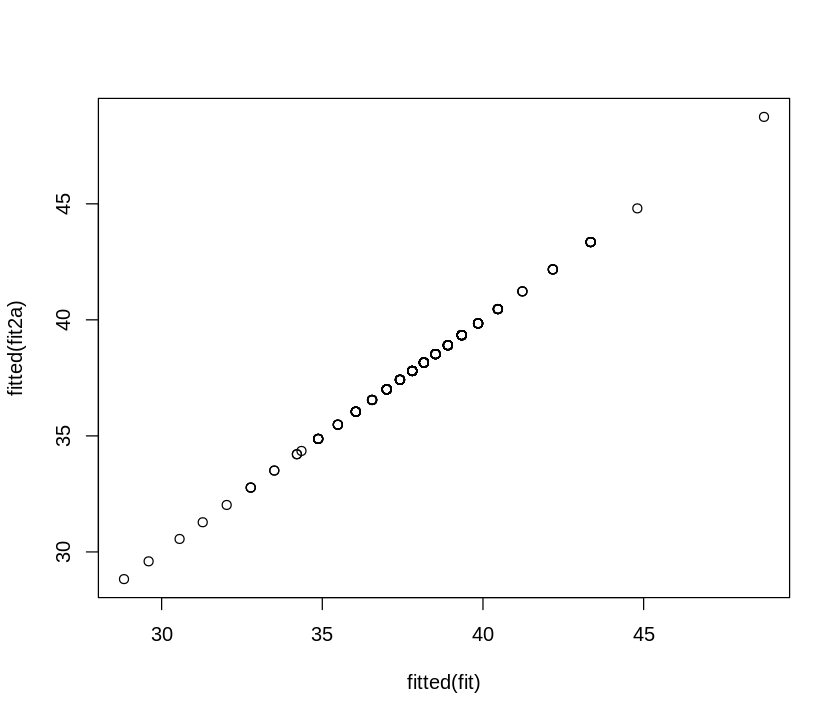

In [ ]:
plot(fitted(fit),fitted(fit2a))

#### C-Bind: Polynomial

The polynomial model can also be specified using the `cbind()` function to manually combine powers of serum sodium into a matrix of predictors.

The resulting fitted values are identical:

In [ ]:
fit2b <- lm(ejection_fraction ~ cbind(serum_sodium, serum_sodium^2, serum_sodium^3, serum_sodium^4),
    data = HeartFailure)

This further demonstrates that different formulations of the polynomial model yield the same results:

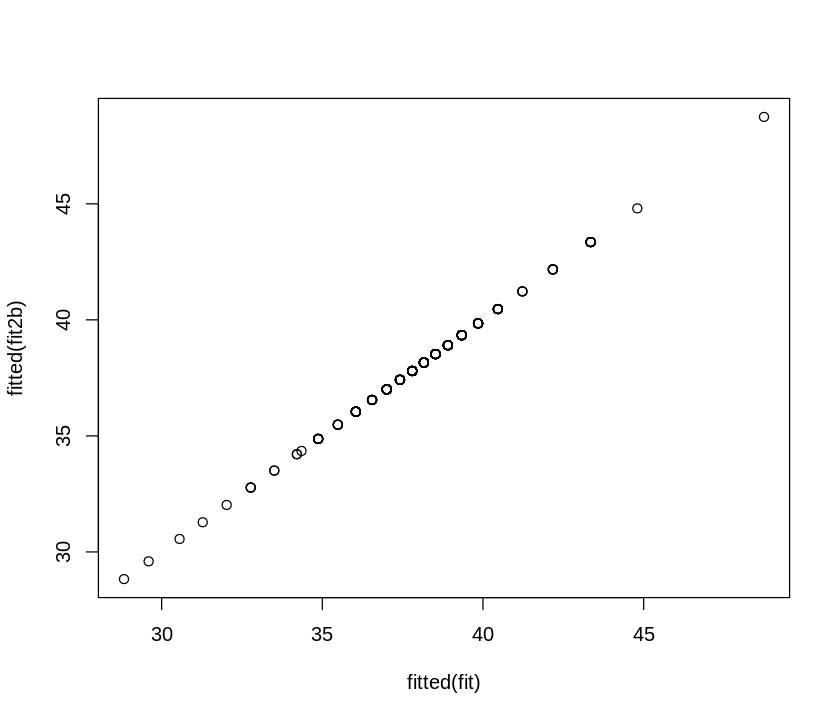

In [ ]:
plot(fitted(fit),fitted(fit2b))

#### Predictions

A grid of serum sodium values was created spanning the observed range in the data to generate smooth predictions from the fitted model.

In [ ]:
attach(HeartFailure)

In [ ]:
serum_sodiumlims <- range(serum_sodium)
serum_sodium.grid <- seq(from = serum_sodiumlims[1], to = serum_sodiumlims[2])
serum_sodium.grid


[1] 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
[20] 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148

The `predict()` function was used to estimate ejection fraction at each point, along with standard errors. These were used to construct confidence bands, capturing the uncertainty around the fitted relationship.

In [ ]:
preds <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid),
    se = TRUE)
se.bands <- cbind(preds$fit + 2 * preds$se.fit,
    preds$fit - 2 * preds$se.fit)

A fourth-degree polynomial is used here to illustrate how nonlinear relationships can be modeled and visualized.

While this allows for flexible curvature, the previous analysis shows that higher-order terms are not statistically significant, indicating that this level of complexity may not necessary for the dataset Heart Failure.

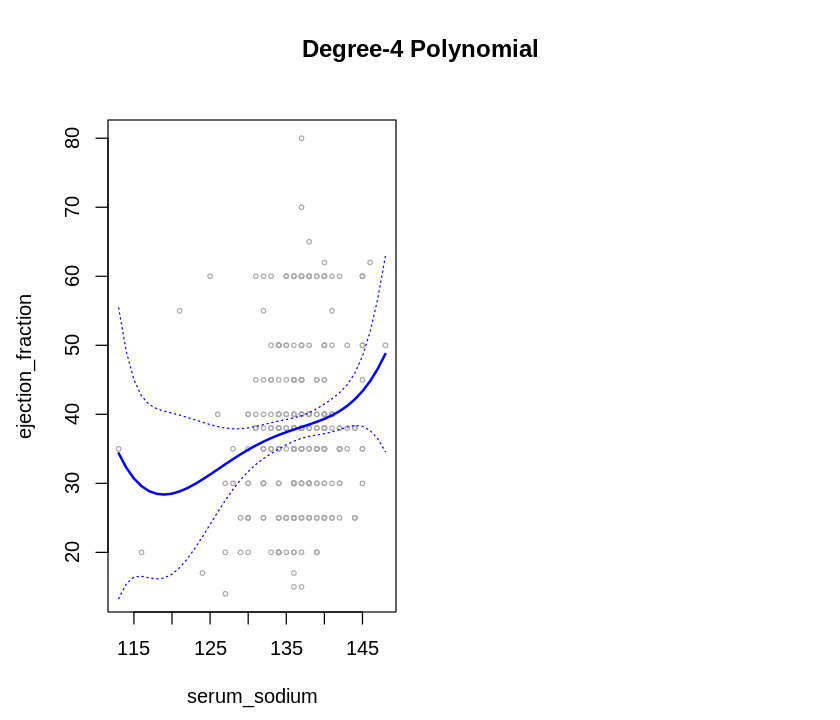

In [ ]:
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 1, 1),
    oma = c(0, 0, 4, 0))
plot(serum_sodium, ejection_fraction, xlim = serum_sodiumlims, cex = .5, col = "darkgrey")
title("Degree-4 Polynomial", outer = T)
lines(serum_sodium.grid, preds$fit, lwd = 2, col = "blue")
matlines(serum_sodium.grid, se.bands, lwd = 1, col = "blue", lty = 3)

The difference between predictions from the orthogonal and raw polynomial models is effectively zero $(\approx 1.5 \times 10^{-9})$, confirming that both approaches produce identical fitted values.

In [ ]:
preds2 <- predict(fit2, newdata = list(serum_sodium = serum_sodium.grid),
    se = TRUE)
max(abs(preds$fit - preds2$fit))

[1] 1.51018e-09

To determine the appropriate level of model complexity, polynomial regressions of increasing degree were compared using an `ANOVA` framework. This approach tests whether adding higher-order terms significantly improves model fit.

In [ ]:
fit.1 <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure)
fit.2 <- lm(ejection_fraction ~ poly(serum_sodium, 2), data = HeartFailure)
fit.3 <- lm(ejection_fraction ~ poly(serum_sodium, 3), data = HeartFailure)
fit.4 <- lm(ejection_fraction ~ poly(serum_sodium, 4), data = HeartFailure)
fit.5 <- lm(ejection_fraction~ poly(serum_sodium, 5), data = HeartFailure)
anova(fit.1, fit.2, fit.3, fit.4, fit.5)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,297,40447.44,NA,NA,NA,NA
2,296,40402.14,1,45.30202588,0.3315162474,0.5652096
3,295,40402.12,1,0.01550977,0.0001134991,0.9915071
4,294,40318.55,1,83.57770216,0.6116142855,0.4348122
5,293,40038.74,1,279.80302862,2.0475739941,0.1535146


The results show that moving from a linear to a quadratic model does not provide a significant improvement `(p = 0.565)`, and additional higher-order terms also fail to improve the model `(p-values of 0.991, 0.435, and 0.154)`.

The coefficient summary of the fifth-degree polynomial confirms these results. Only the first term is statistically significant (p ≈ 0.0023), while all higher-order terms have large p-values. This provides the same conclusion as the ANOVA analysis, demonstrating that additional polynomial terms do not improve the model.

In [ ]:
coef(summary(fit.5))

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),38.0836120,0.6760375,56.3335764,3.088435e-159
"poly(serum_sodium, 5)1",35.9370169,11.6897818,3.0742248,2.309345e-03
"poly(serum_sodium, 5)2",6.7306780,11.6897818,0.5757745,5.652096e-01
"poly(serum_sodium, 5)3",-0.1245382,11.6897818,-0.0106536,9.915071e-01
"poly(serum_sodium, 5)4",9.1420841,11.6897818,0.7820577,4.348122e-01
"poly(serum_sodium, 5)5",16.7273138,11.6897818,1.4309347,1.535146e-01


The p-values from the coefficient summary match those from ANOVA. In this case, the square of the t-statistic equals the F-statistic (e.g., $(0.575)^2 \approx 0.331$), confirming that both methods yield the same results.

In [ ]:
(0.575)^2

[1] 0.330625

Based on earlier results showing that higher-order polynomial terms for serum sodium do not improve model fit, serum sodium is modeled as a linear term. This ensures that any changes in model performance are driven by the inclusion of nonlinear age terms rather than unnecessary complexity in serum sodium.

In [ ]:
fit.1 <- lm(ejection_fraction ~ serum_sodium + age, data = HeartFailure)
fit.2 <- lm(ejection_fraction ~ serum_sodium + poly(age, 2), data = HeartFailure)
fit.3 <- lm(ejection_fraction ~ serum_sodium + poly(age, 3), data = HeartFailure)
anova(fit.1, fit.2, fit.3)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,296,40252.98,NA,NA,NA,NA
2,295,40239.03,1,13.955856,0.10197934,0.7496939
3,294,40233.85,1,5.178577,0.03784131,0.8458965


ANOVA results comparing linear, quadratic, and cubic `age` models show no significant improvement from adding higher-order terms (p = 0.7497 and p = 0.8459).

### Ejection Fraction: Classification

To further analyze the relationship, the outcome is transformed into a binary variable indicating whether` ejection fraction` is below 30, representing a clinically relevant threshold. A logistic regression model is then fitted using the `glm()` function with a binomial family, allowing the estimation of the probability of low `ejection fraction` as a function of `serum sodium`.

Initially, a nonlinear logistic regression model is fitted using polynomial terms of `serum sodium` to allow for potential curvature in the relationship. This may find any complex patterns in the probability of low `ejection fraction`; however, previous analysis demonstrates a simpler model may be a better choice.

In [ ]:
fit <- glm(I(ejection_fraction < 30) ~ poly(serum_sodium,4), data = HeartFailure,
    family = binomial)

The binary response variable is created using the `I()` function, where the condition `(ejection_fraction < 30)` produces logical values of TRUE and FALSE. These are automatically converted by `glm()` into a binary outcome, with TRUE coded as 1 and FALSE as 0.

Predictions are then obtained using the `predict()` function:

In [ ]:
preds <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid), se = T)

Predictions from a logistic regression model are initially expressed in terms of log-odds, $X\hat{\beta}$. To obtain probabilities, the logistic transformation is applied:

$$
\Pr(Y=1|X) = \frac{\exp(X\beta)}{1 + \exp(X\beta)}
$$

This transformation is also used to construct confidence intervals on the probability scale.

In [ ]:
pfit <- exp(preds$fit) / (1 + exp(preds$fit))
se.bands.logit <- cbind(preds$fit + 2 * preds$se.fit,
    preds$fit - 2 * preds$se.fit)
se.bands <- exp(se.bands.logit) / (1 + exp(se.bands.logit))

Note that the probabilities could have been directly computed by selecting the `type = "response"` option in the `predict()` function. However, the corresponding confidence intervals would not have been sensible due to negative probabilities.

In [ ]:
preds <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid),
    type = "response", se = T)



Finally, the right-hand plot was made as follows:

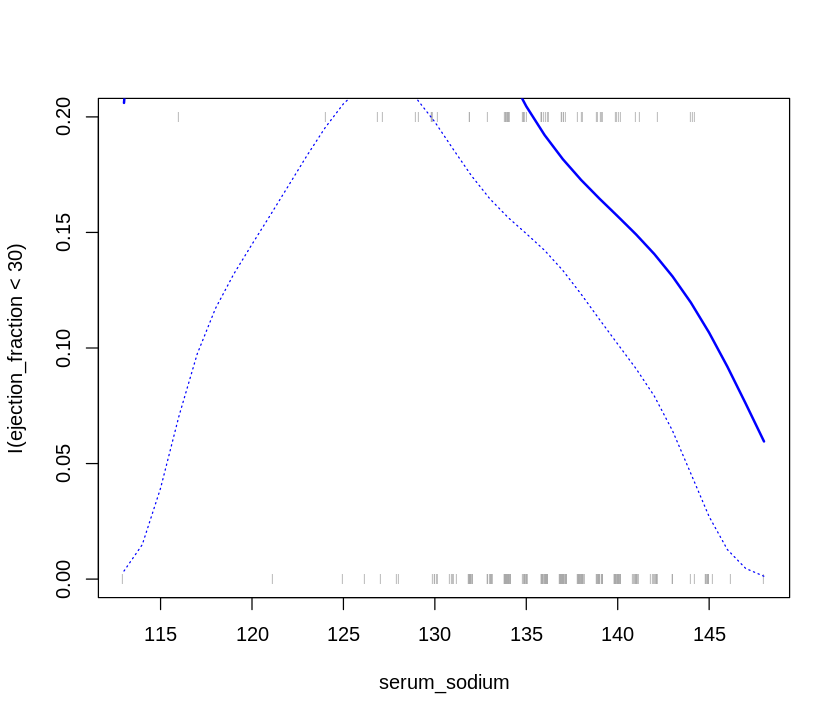

In [ ]:
plot(serum_sodium, I(ejection_fraction < 30), xlim = serum_sodiumlims, type = "n",
    ylim = c(0, .2))
points(jitter(serum_sodium), I((ejection_fraction < 30) / 5), cex = .5, pch = "|", col = "darkgrey")
lines(serum_sodium.grid, pfit, lwd = 2, col = "blue")
matlines(serum_sodium.grid, se.bands, lwd = 1, col = "blue", lty = 3)

The nonlinear logistic model suggests an overall decreasing relationship between serum sodium and the probability of low `ejection fraction`. However, the fitted curve has irregular fluctuations and wide confidence bands, showing possible instability and high uncertainty.

 These patterns are consistent with earlier findings showing that higher-order terms are not statistically significant, and that the apparent nonlinearity could reflect overfitting.

Therefore, the same logistic regression model was fit for a simpler linear model:

In [ ]:
fit <- glm(I(ejection_fraction < 30) ~ serum_sodium, data = HeartFailure,
    family = binomial)

In [ ]:
preds <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid), se = T)

In [ ]:
pfit <- exp(preds$fit) / (1 + exp(preds$fit))
se.bands.logit <- cbind(preds$fit + 2 * preds$se.fit,
    preds$fit - 2 * preds$se.fit)
se.bands <- exp(se.bands.logit) / (1 + exp(se.bands.logit))

In [ ]:
preds <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid),
    type = "response", se = T)

The linear logistic regression model shows a clear decreasing relationship between `serum sodium` and the probability of low `ejection fraction`.

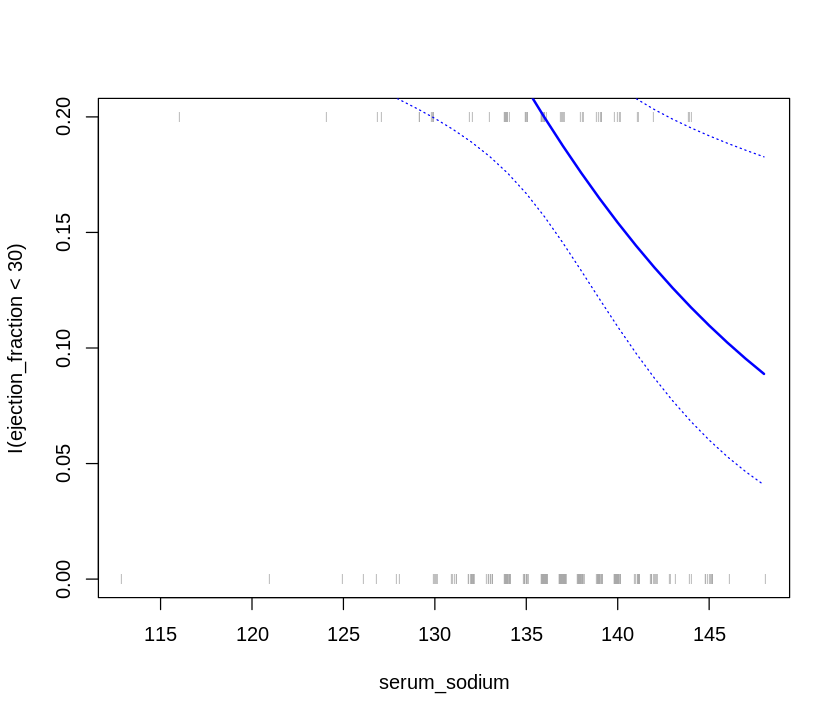

In [ ]:
plot(serum_sodium, I(ejection_fraction < 30), xlim = serum_sodiumlims, type = "n",
    ylim = c(0, .2))
points(jitter(serum_sodium), I((ejection_fraction < 30) / 5), cex = .5, pch = "|", col = "darkgrey")
lines(serum_sodium.grid, pfit, lwd = 2, col = "blue")
matlines(serum_sodium.grid, se.bands, lwd = 1, col = "blue", lty = 3)

## Step Functions

The step function model divides serum sodium into four intervals and compares the average ejection fraction. Compared to the baseline group (113–122), none of the intervals are statistically significant, with p-values of $0.324, 0.839$, and $0.590$.

In [ ]:
table(cut(serum_sodium, 4))
fit <- lm(ejection_fraction ~ cut(serum_sodium, 4), data = HeartFailure)
coef(summary(fit))


(113,122] (122,130] (130,139] (139,148] 
        3        19       200        77 

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),36.666667,6.717958,5.4580076,1.021817e-07
"cut(serum_sodium, 4)(122,130]",-7.140351,7.228894,-0.9877515,3.240838e-01
"cut(serum_sodium, 4)(130,139]",1.373333,6.768155,0.2029110,8.393445e-01
"cut(serum_sodium, 4)(139,148]",3.696970,6.847577,0.5398946,5.896770e-01


Similarly, the step function model for age divides the data into four intervals and compares average ejection fraction. None of the intervals show statistically significant differences relative to the baseline group (39.9–53.8), with p-values of $0.648, 0.958$, and $0.082$.


In [ ]:
table(cut(age, 4))
fit <- lm(ejection_fraction ~ cut(age, 4), data = HeartFailure)
coef(summary(fit))


(39.9,53.8] (53.8,67.5] (67.5,81.2] (81.2,95.1] 
         93         121          68          17 

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),37.49462366,1.226500,30.57042833,1.935974e-93
"cut(age, 4)(53.8,67.5]",0.74504577,1.631104,0.45677389,6.481697e-01
"cut(age, 4)(67.5,81.2]",-0.09756483,1.887235,-0.05169724,9.588049e-01
"cut(age, 4)(81.2,95.1]",5.44655281,3.119891,1.74575125,8.189525e-02


The lack of significant differences across intervals for both serum sodium and age, may mean that there are minimal threshold effects. These findings, combined with the earlier lack of polynomial significance, further demonstrates that a linear model is sufficient.

## Splines

In [ ]:
install.packages('splines')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘splines’ is a base package, and should not be updated”


Regression splines can be fit by constructing an appropriate matrix of basis functions. A cubic regression spline was fit to model the relationship between `serum sodium` and `ejection fraction`. The spline allows for flexible, piecewise cubic behavior with smooth transitions at the knot locations.

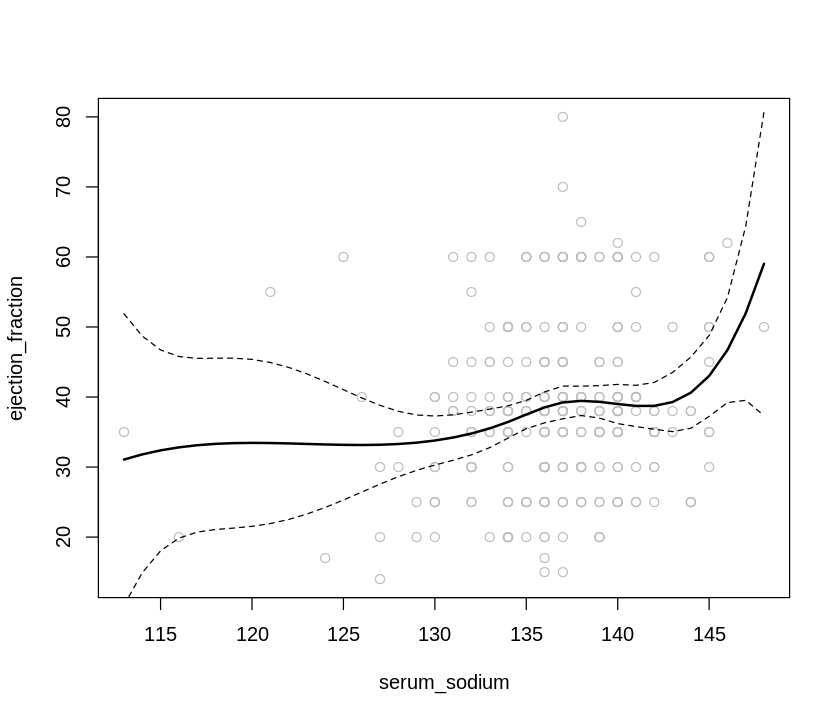

In [ ]:
library(splines)
fit <- lm(ejection_fraction ~ bs(serum_sodium, knots = c(134, 137, 140)), data = HeartFailure)
pred <- predict(fit, newdata = list(serum_sodium = serum_sodium.grid), se = T)
plot(serum_sodium, ejection_fraction, col = "gray")
lines(serum_sodium.grid, pred$fit, lwd = 2)
lines(serum_sodium.grid, pred$fit + 2 * pred$se, lty = "dashed")
lines(serum_sodium.grid, pred$fit - 2 * pred$se, lty = "dashed")

While the fitted curve could mean slight nonlinearity, especially at higher sodium levels, the wide confidence intervals in these areas also show large uncertainty.

Here the prespecified knots at serum sodium levels were $134$, $137$, and $140$. This produces a spline with six basis functions.

This is consistent with uniform quantiles of the data:

In [ ]:
dim(bs(serum_sodium, knots = c(25, 40, 60)))
dim(bs(serum_sodium, df = 6))
attr(bs(serum_sodium, df = 6), "knots")

[1] 299   6

[1] 299   6

[1] 134 137 140

`R` chooses knots at the levels used in the analysis, $134, 137$, and $140$, as they correspond to the 25th, 50th, and 75th percentiles of `serum sodium`.

Here we fit a natural spline with four degrees of freedom:

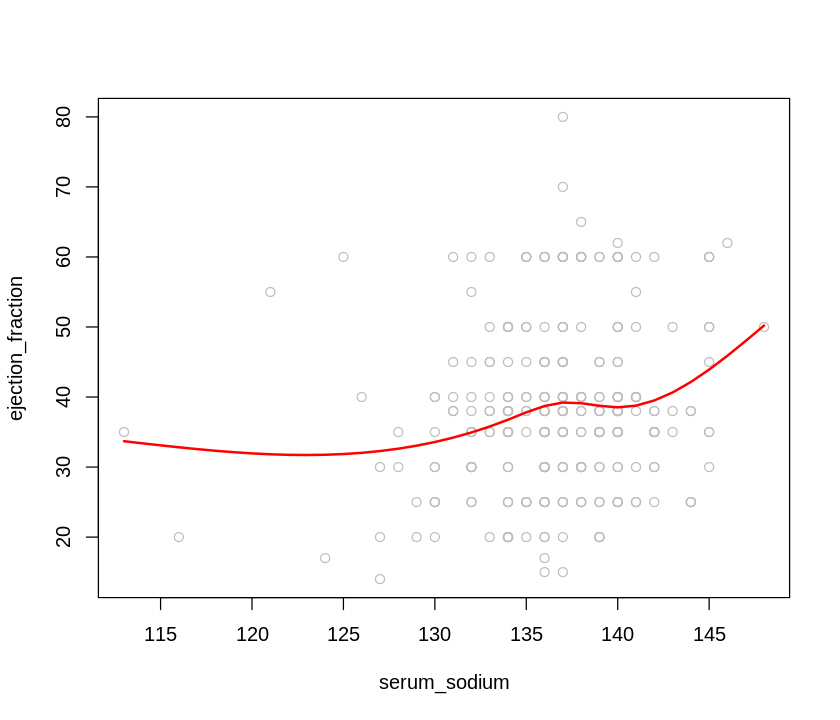

In [ ]:
fit2 <- lm(ejection_fraction ~ ns(serum_sodium, df = 4), data = HeartFailure)
pred2 <- predict(fit2, newdata = list(serum_sodium = serum_sodium.grid),
     se = T)
plot(serum_sodium, ejection_fraction, col = "gray")
lines(serum_sodium.grid, pred2$fit, col = "red", lwd = 2)

A natural spline with 4 degrees of freedom was fit to model the relationship between `serum sodium `and `ejection fraction`. Compared to the cubic regression spline, the natural spline imposes linearity at the boundaries, leading to a smoother fit.

Unlike the previous spline, no extreme behavior is observed at the boundaries, meaning that earlier spikes may have been due to overfitting.

A smoothing spline was fit to the data using two levels of flexibility:

Warning message in smooth.spline(serum_sodium, ejection_fraction, cv = TRUE):
“cross-validation with non-unique 'x' values seems doubtful”


[1] 2.000012

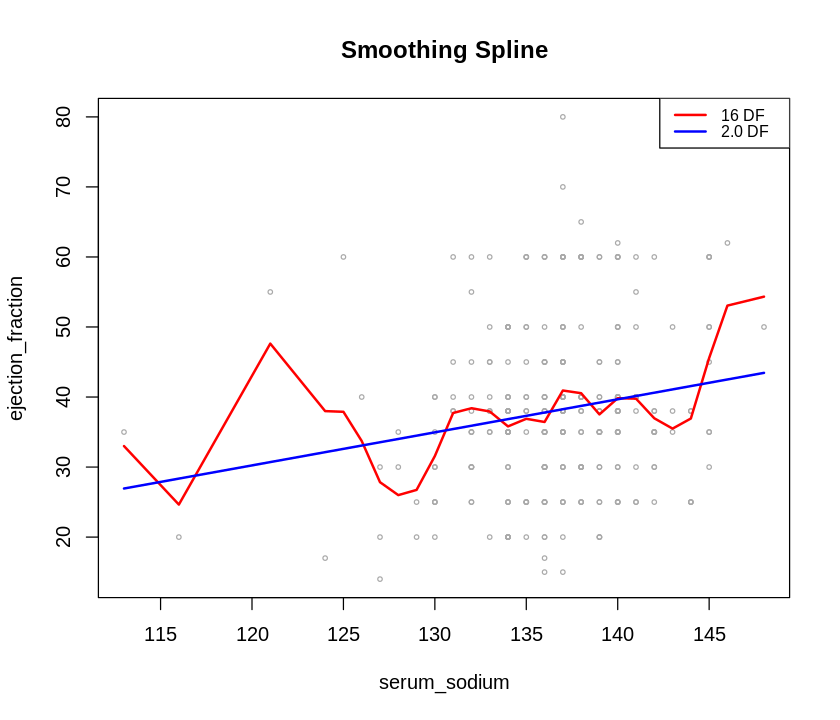

In [ ]:
plot(serum_sodium, ejection_fraction, xlim = serum_sodiumlims, cex = .5, col = "darkgrey")
title("Smoothing Spline")
fit <- smooth.spline(serum_sodium, ejection_fraction, df = 16)
fit2 <- smooth.spline(serum_sodium, ejection_fraction, cv = TRUE)
fit2$df
lines(fit, col = "red", lwd = 2)
lines(fit2, col = "blue", lwd = 2)
legend("topright", legend = c("16 DF", "2.0 DF"),
    col = c("red", "blue"), lty = 1, lwd = 2, cex = .8)

The curve with 16 degrees of freedom follows the data closely and shows sharp fluctuations, capturing local variation but also noise.

The cross-validated spline (≈2 degrees of freedom) is much smoother, producing a gradual upward trend without abrupt changes. This stark difference is because the cross validation selected the smoothness level that gave the lowest prediction error. Once again, there seems to be no strong nonlinear pattern.

## Local Regression

Here local linear regression is performed using spans of $0.2$ and $0.5$: that is, each neighborhood consists of 20\,\% or 50\,\% of the observations. The larger the span, the smoother the fit.

The `loess()` function is utilized:

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at 136”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 1”


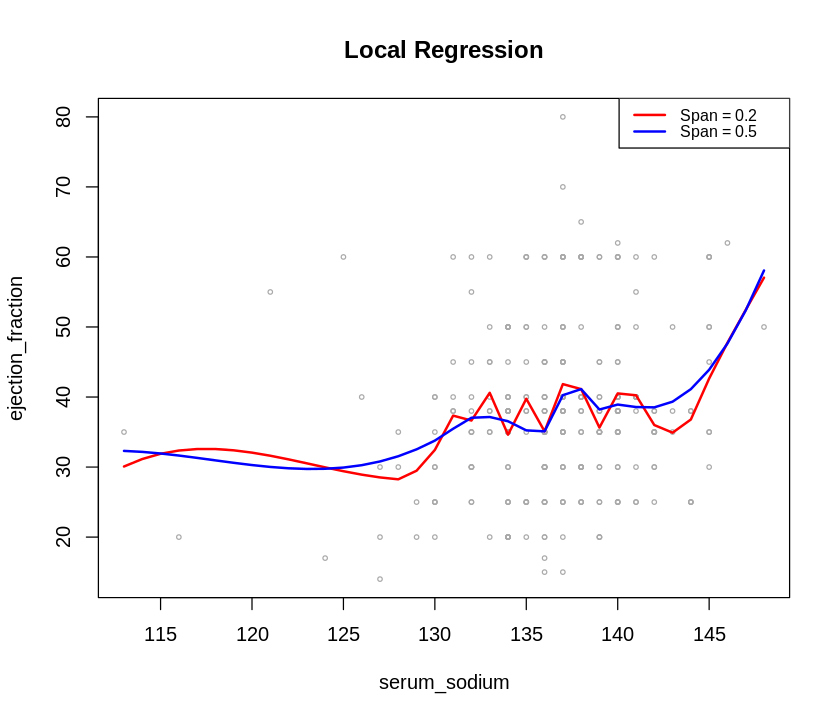

In [ ]:
plot(serum_sodium, ejection_fraction, xlim = serum_sodiumlims, cex = .5, col = "darkgrey")
title("Local Regression")
fit <- loess(ejection_fraction ~ serum_sodium, span = .2, data = HeartFailure)
fit2 <- loess(ejection_fraction ~ serum_sodium, span = .5, data = HeartFailure)
lines(serum_sodium.grid, predict(fit, data.frame(serum_sodium = serum_sodium.grid)),
    col = "red", lwd = 2)
lines(serum_sodium.grid, predict(fit2, data.frame(serum_sodium = serum_sodium.grid)),
    col = "blue", lwd = 2)
legend("topright", legend = c("Span = 0.2", "Span = 0.5"),
    col = c("red", "blue"), lty = 1, lwd = 2, cex = .8)

The loess curve with span = 0.2 follows the data more closely and shows several fluctuations, capturing local variation especially around 130-140. The curve with span = 0.5 is smoother and highlights the overall pattern, showing a gradual increase in ejection fraction as serum sodium rises. The 130-140 region is notably smoother, and the drop from 140-145 is also much reduced.

## GAMs

The model incorporates natural spline functions for `serum sodium `and `age` to allow for nonlinear relationships, while sex is included as a linear term.

In [ ]:
install.packages('gam')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’




In [ ]:
library(gam)

Loading required package: foreach

Loaded gam 1.22-7




In [ ]:
gam1 <- lm(ejection_fraction ~ ns(serum_sodium, 4) + ns(age, 5) + sex,
    data = HeartFailure)

The model is now fit using smoothing splines rather than natural splines.  

Using the `gam` library, a smoothing spline is used and it is specified that the function of `serum_sodium` should have $4$ degrees of freedom, and that the function of `age` will have $5$ degrees of freedom.

Since `sex` is qualitative, it is left as is.

The `gam()` function is used in order to fit a GAM using these components. All of the terms are fit simultaneously, taking each other into account to explain the response.

In [ ]:
library(gam)
gam.m3 <- gam(ejection_fraction ~ ns(serum_sodium, 4) + ns(age, 5) + sex,
    data = HeartFailure)

The estimated effect of `serum sodium `shows mild curvature, with a small dip followed by an increase. However, the wide confidence bands and earlier model comparisons indicate that this nonlinearity is weak.

The effect of `age` is mostly flat across mid-range values, with an increase at higher ages. The upward trend at older ages is accompanied by wide confidence bands, which could mean potentially greater uncertainty.

`Sex` enters the model as a categorical variable, producing a constant difference in ejection fraction between the groups, with one group being associated with lower values.

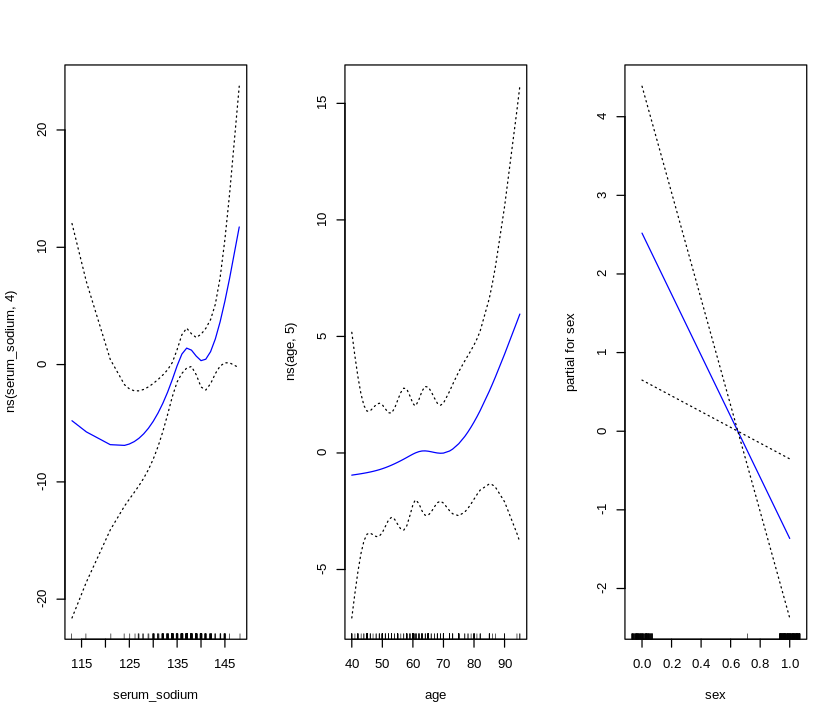

In [ ]:
par(mfrow = c(1, 3))
plot(gam.m3, se = TRUE, col = "blue")

The plots are very similar, although one model is fit using `lm()` and the other using `gam()`:

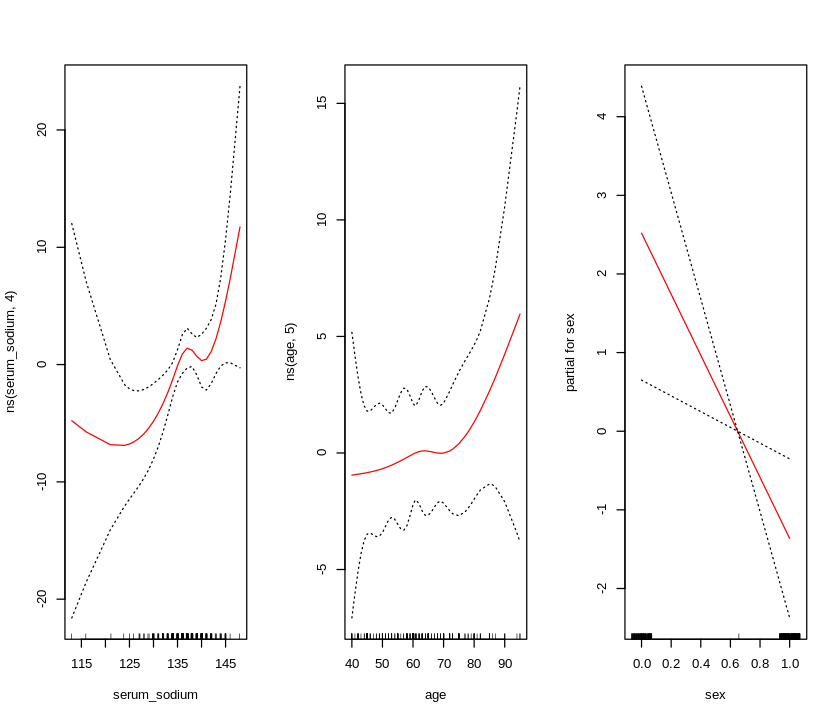

In [ ]:
par(mfrow = c(1, 3))
plot.Gam(gam1, se = TRUE, col = "red")

A series of ANOVA tests is performed in order to determine which of these three models is best: a GAM that excludes `serum_sodium` ($\mathcal{M}_1$), a GAM that uses a linear function of `serum_sodium` ($\mathcal{M}_2$), or  a GAM that uses a spline function of `serum_sodium` ($\mathcal{M}_3$).

In [ ]:
gam.m1 <- gam(ejection_fraction ~  ns(age, 5) + sex, data = HeartFailure)
gam.m2 <- gam(ejection_fraction~  ns(age, 5) + serum_sodium + sex,
    data = HeartFailure)
anova(gam.m1, gam.m2, gam.m3, test = "F")

,Resid. Df,Resid. Dev,Df,Deviance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,292,40552.47,NA,NA,NA,NA
2,291,39271.43,1,1281.047,9.502719,0.002250468
3,288,38824.84,3,446.585,1.104246,0.347707522


The ANOVA results show that adding serum sodium as a predictor significantly improves the model compared to excluding it (p = 0.0023). However, allowing for a nonlinear spline effect does not provide an improvement over the linear model(p = 0.3477).

The `summary()` function produces a summary of the gam fit:

In [ ]:
summary(gam.m3)


Call: gam(formula = ejection_fraction ~ ns(serum_sodium, 4) + ns(age, 
    5) + sex, data = HeartFailure)
Deviance Residuals:
    Min      1Q  Median      3Q     Max 
-25.589  -7.620  -1.382   5.748  38.838 

(Dispersion Parameter for gaussian family taken to be 134.8085)

    Null Deviance: 41738.91 on 298 degrees of freedom
Residual Deviance: 38824.84 on 288 degrees of freedom
AIC: 2327.57 

Number of Local Scoring Iterations: 2 

Anova for Parametric Effects
                     Df Sum Sq Mean Sq F value   Pr(>F)   
ns(serum_sodium, 4)   4   1669  417.20  3.0948 0.016184 * 
ns(age, 5)            5    266   53.11  0.3940 0.852800   
sex                   1    980  979.69  7.2672 0.007435 **
Residuals           288  38825  134.81                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


The model reduces deviance from 41738.91 to 38824.84, indicating a modest improvement in fit. `Serum sodium` contributes significantly (F = 3.09, p = 0.016), accounting for a portion of the explained variation (Sum Sq = 1669), while sex also has a strong effect (F = 7.27, p = 0.007, Sum Sq = 980).

In contrast, `age` provides very minimal explanatory power (F = 0.39, p = 0.853, Sum Sq = 266). Combined with earlier ANOVA results, this supports including serum sodium as a predictor, but without a nonlinear spline, and shows that `age` may not improve the model.

Predictions are made using the `predict()` method for the class `Gam`. Here predictions are made on the training set:

In [ ]:
preds <- predict(gam.m2, newdata = HeartFailure)

Local regression fits can also be used as building blocks in a GAM, using the `lo()` function:

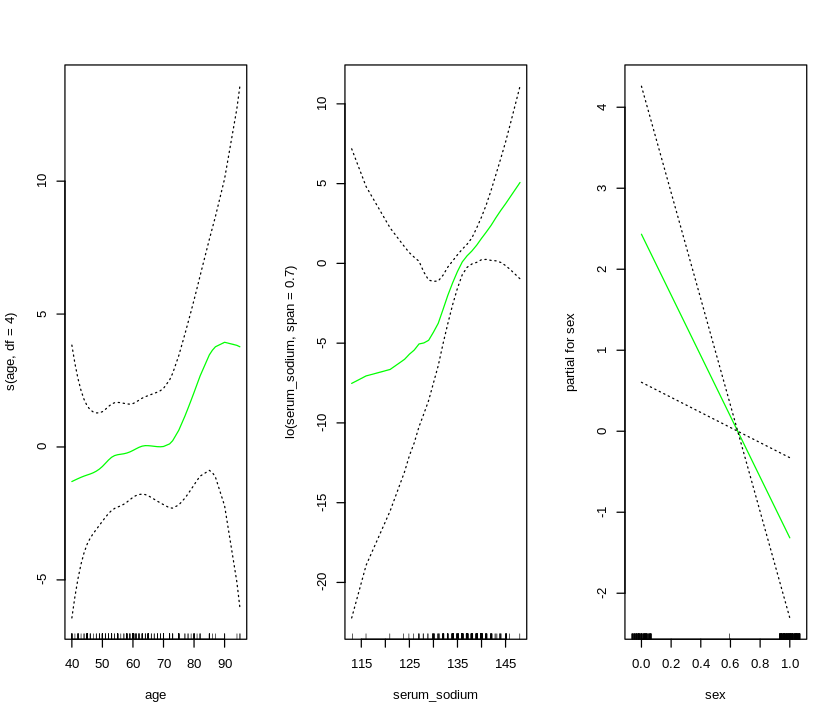

In [ ]:
par(mfrow = c(1, 3))
gam.lo <- gam(
    ejection_fraction ~ s(age, df = 4) + lo(serum_sodium, span = 0.7) + sex,
    data = HeartFailure
  )
plot.Gam(gam.lo, se = TRUE, col = "green")

Here local regression is used for the `serum_sodium` term, with a span of $0.7$.The model shows a weak, slightly increasing pattern for age, a noisy and unstable loess fit for serum sodium, and a clear linear decrease for sex.



The `lo()` function can also be used to create interactions before calling the `gam()` function. For example:

In [ ]:
gam.lo.i <- gam(ejection_fraction ~ lo(serum_sodium, age, span = 0.5) + sex,
    data = HeartFailure)

fits a two-term model, in which the first term is an interaction between `serum_sodium` and `age`, fit by a local regression surface. This results in a two-dimensional surface, and is plotted using the `akima` package.

In [ ]:
install.packages('akima')
install.packages('interp')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘sp’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘deldir’, ‘RcppEigen’




In [ ]:
library(akima)

In [ ]:
library(interp)


Attaching package: ‘interp’


The following objects are masked from ‘package:akima’:

    aspline, bicubic, bicubic.grid, bilinear, bilinear.grid,
    franke.data, franke.fn, interp, interp2xyz, interpp




The model includes a two-dimensional loess surface for `serum sodium` and `age`, showing their joint effect on `ejection fraction`, which looks irregular and highly variable.

On the other hand, `sex` once again shows a clear linear decrease.

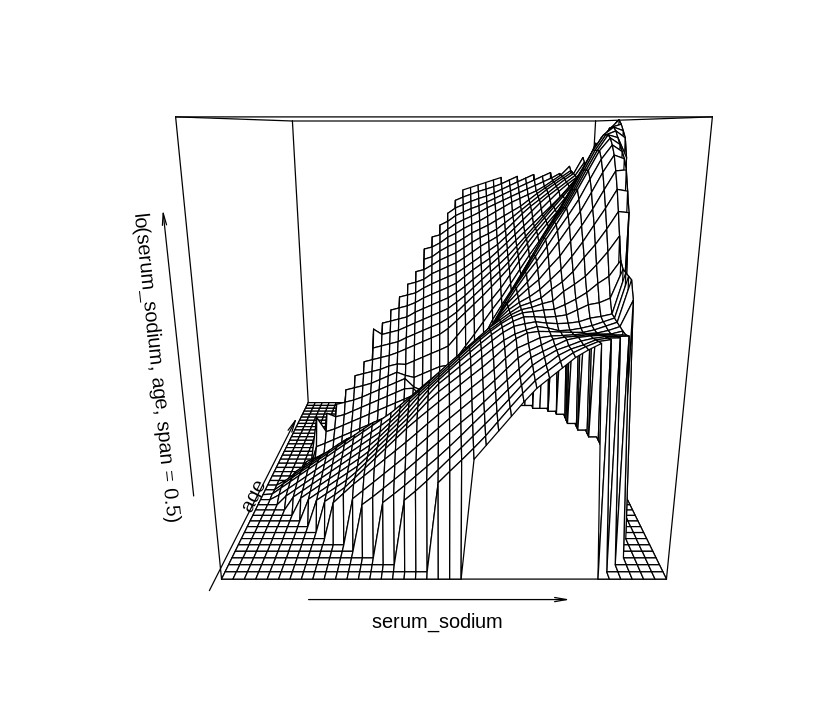

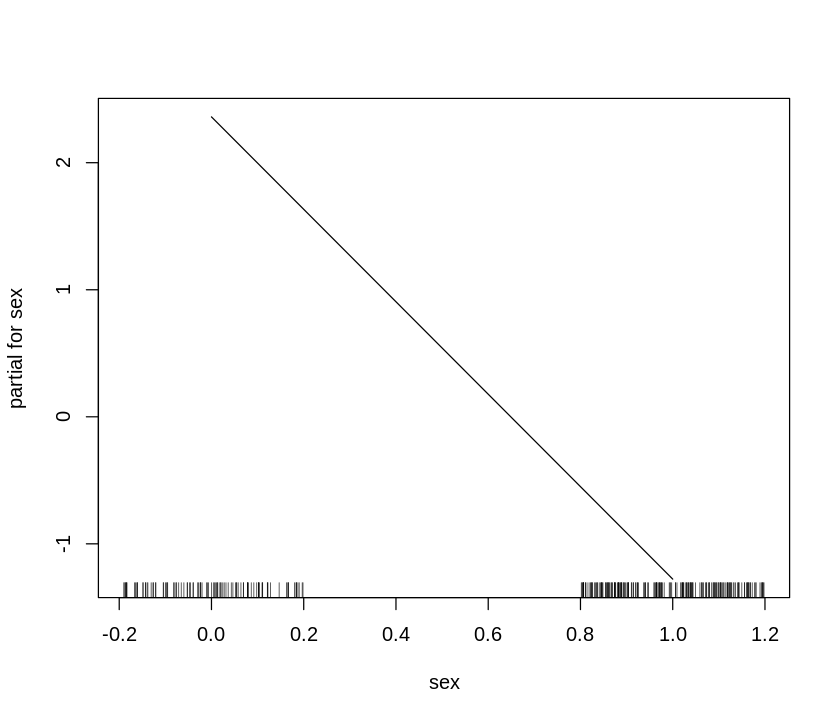

In [ ]:
library(akima)
plot(gam.lo.i)

### Classification: Ejection Fraction GAM

In order to fit a logistic regression GAM, the `I()` function is used in constructing the binary response variable, and set `family=binomial`:

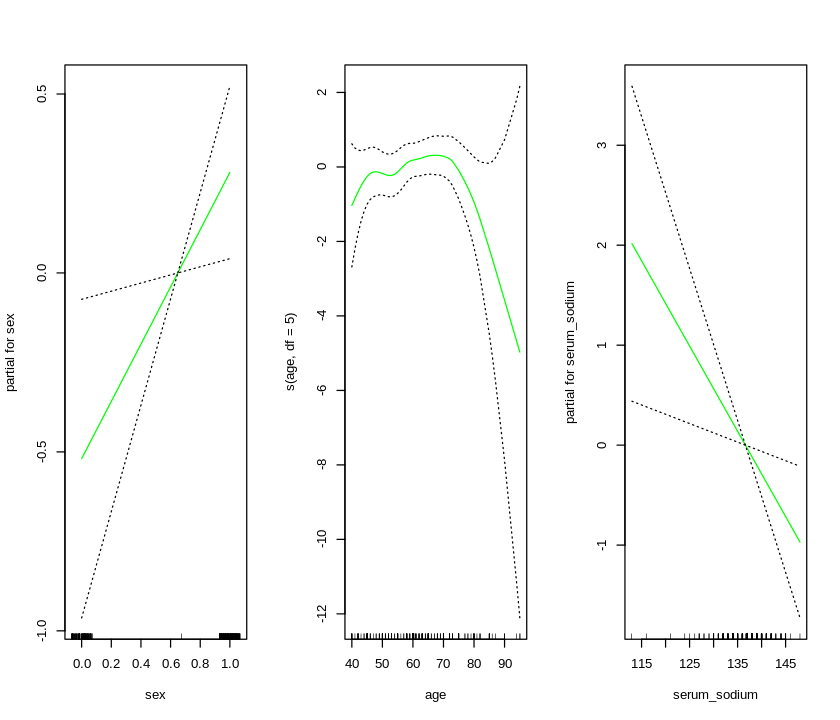

In [ ]:
gam.lr <- gam(
    I(ejection_fraction < 30) ~ sex + s(age, df = 5) + serum_sodium,
    family = binomial, data = HeartFailure
  )
par(mfrow = c(1, 3))
plot(gam.lr, se = T, col = "green")

Individuals in the group coded as 1(males) have a higher proportion of low `ejection fraction `(23.2%) compared to those coded as 0 (females) (13.3%), demonstrating a meaningful difference.

In [ ]:
table(sex, I(ejection_fraction < 30))

   
sex FALSE TRUE
  0    91   14
  1   149   45

In [ ]:
14/(91+14)
45/(149+45)

[1] 0.1333333

[1] 0.2319588

In [ ]:
table(serum_sodium, I(ejection_fraction < 30))

            
serum_sodium FALSE TRUE
         113     1    0
         116     0    1
         121     1    0
         124     0    1
         125     1    0
         126     1    0
         127     1    2
         128     2    0
         129     0    2
         130     5    4
         131     5    0
         132    12    2
         133     9    1
         134    23    9
         135    11    5
         136    31    9
         137    33    5
         138    20    3
         139    17    5
         140    31    4
         141    10    2
         142    10    1
         143     3    0
         144     2    3
         145     9    0
         146     1    0
         148     1    0

In [ ]:
table(age, I(ejection_fraction < 30))

        
age      FALSE TRUE
  40         7    0
  41         1    0
  42         6    1
  43         1    0
  44         2    0
  45        15    4
  46         2    1
  47         0    1
  48         2    0
  49         3    1
  50        22    5
  51         3    1
  52         5    0
  53         9    1
  54         2    0
  55        15    2
  56         1    0
  57         1    1
  58         7    3
  59         1    3
  60        25    8
  60.667     2    0
  61         4    0
  62         4    1
  63         7    1
  64         2    1
  65        18    8
  66         2    0
  67         2    0
  68         3    2
  69         2    1
  70        21    4
  72         3    4
  73         3    1
  75         9    2
  77         2    0
  78         2    0
  79         1    0
  80         5    2
  81         1    0
  82         3    0
  85         6    0
  86         1    0
  87         1    0
  90         3    0
  94         1    0
  95         2    0

While some individual values of `age` and `serum sodium` have no observations of low `ejection fraction`, these variables are treated as continuous predictors. Unlike categorical variables, there is no need to remove any values, and the full dataset can be used.

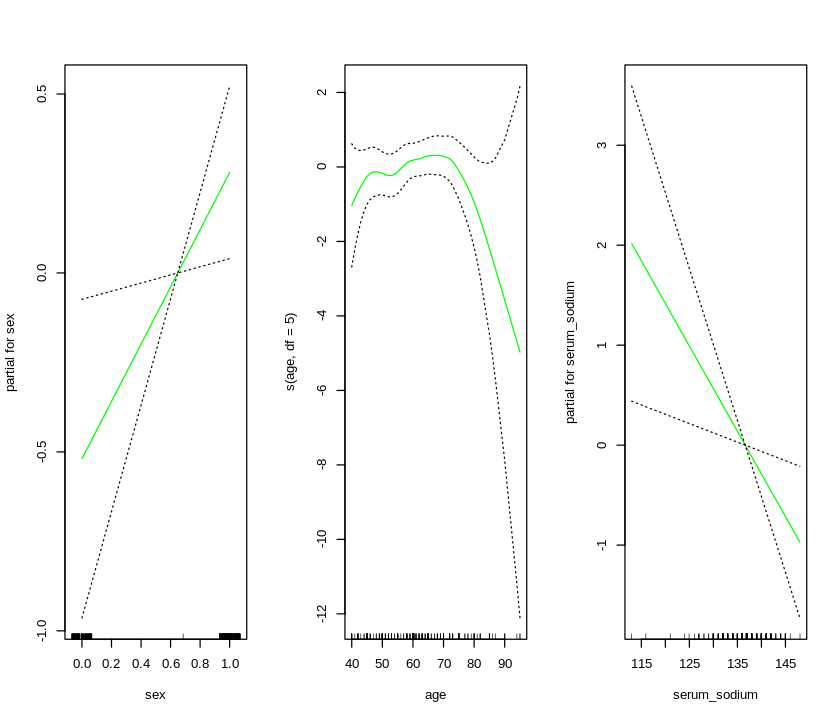

In [ ]:
gam.lr.s <- gam(
    I(ejection_fraction < 30) ~ sex + s(age, df = 5) + serum_sodium,
    family = binomial, data = HeartFailure,
  )
par(mfrow = c(1, 3))
plot(gam.lr.s, se = T, col = "green")

# 4. Results

##Previous Relevant Results

#### Regression

Serum sodium was a statistically significant positive predictor of ejection fraction (p = 0.0023). Higher sodium levels were associated with
higher ejection fraction values, with a small but significant linear relationship. Sex was found to be a statistically significant predictor of ejection fraction (β = −3.673, p = 0.0102). The negative coefficient indicates that
males (coded as 1) have, on average, a 3.67 percentage point lower ejection fraction compared to females (coded as 0).

These findings suggest that both physiological factors (serum sodium) and demographic characteristics (sex) may play a role in explaining variation in cardiac function within this heart failure population, although the overall *effect sizes* indicate that additional factors likely contribute to variability.


Call:
lm(formula = ejection_fraction ~ age, data = HeartFailure)

Coefficients:
(Intercept)          age  
    34.4460       0.0598  



Call:
lm(formula = ejection_fraction ~ sex, data = HeartFailure)

Coefficients:
(Intercept)          sex  
     40.467       -3.673  


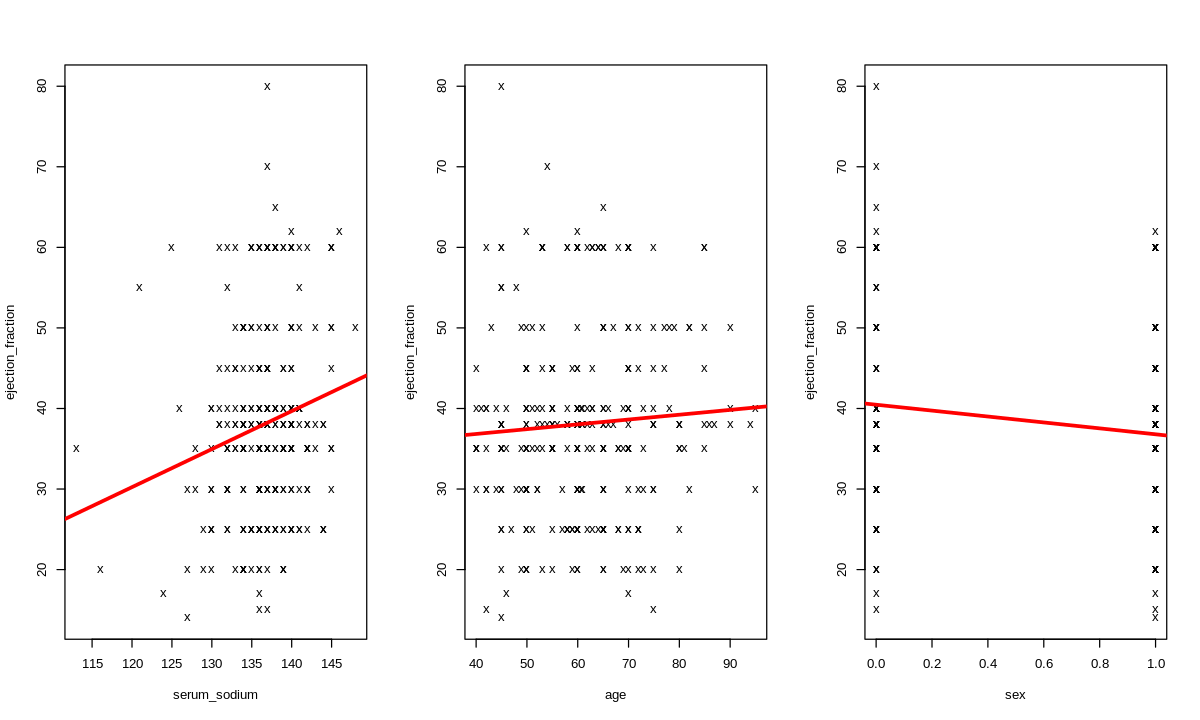

In [ ]:
par(mfrow = c(1, 3))
options(repr.plot.width = 10, repr.plot.height = 6)
plot(serum_sodium, ejection_fraction, pch="x")
abline(lm_sodium1, lwd=3, col="red")
plot(age, ejection_fraction, pch="x")
abline(lm_age1, lwd=3, col="red")
lm_age1
plot(sex, ejection_fraction, pch="x")
abline(lm_sex1, lwd=3, col="red")
lm_sex1

####Classification

Regression analyses indicate that age, serum sodium, and sex are significantly associated with serum creatinine or ejection fraction. These two variables are recognized in prior research as critical indicators of heart failure patient survival.

Four classification techniques were evaluated using a held-out test set of 299 patients to predict the event of death. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only ejection fraction and serum creatinine, test accuracy improved to approximately 85.9%.

This study demonstrates that statistical classification methods can effectively predict mortality risk in heart failure patients using key clinical indicators. In practice, models like these could assist physicians in identifying high-risk patients who may require closer monitoring, more aggressive treatment, or earlier intervention.

##Current Results

To summarize the performance and interpretability of each modeling approach, Table 1 provides a comparison of key results across methods:

In [ ]:
knitr::kable(results, caption = "1: Model Comparison Results")



Table: 1: Model Comparison Results

|Method                               |Nonlinear |Key_Results                                                                          |Interpretation                                                                   |
|:------------------------------------|:---------|:------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------|
|Linear Regression                    |No        |Baseline model                                                                       |Simple linear model is appropiate and statistically significant for serum sodium |
|Polynomial Regression                |Yes       |Serum Sodium: Only first term significant (p≈0.0023); higher-order not significant   |No meaningful nonlinearity                                                       |
|Logistic Regression (Classification) |Yes       |Nonlinear terms unstable; decreasing

The results for the orthogonal polynomial show that only the first polynomial term is statistically significant `(p ≈ 0.0023)`, while higher-order terms `(p-values of 0.565, 0.991, and 0.436)` are not. Additionally, the ANOVA results between nonlinear terms of `serum sodium` further confirmed this as additional higher-order terms also fail to improve the model `(p-values of 0.991, 0.435, and 0.154)`. Furthermore, to analyze the relationship between non-linear terms of `age` with `ejection fraction`, ANOVA was performed again. However, there was also no improvement due to higher order terms `(p=0.7497 and p= 0.8459)`.

 Moreover, classification was performed(ejection fraction < 30). Both the nonlinear and linear logistic regression model showed a decreasing relationship between serum sodium and the probability of low `ejection fraction`.


To further investigate whether nonlinearity may appear in the form of threshold effects rather than smooth curvature, step function models were evaluated. The step function model divides `serum sodium` into four intervals and compares the average ejection fraction. Compared to the baseline group (113–122), none of the intervals are statistically significant, with p-values of $0.324, 0.839$, and $0.590$. Similarly, the step function model for `age` divides the data into four intervals and compares average `ejection fraction`. None of the intervals show statistically significant differences relative to the baseline group (39.9–53.8), with p-values of $0.648, 0.958$, and $0.082$.


While polynomial and step function models did not reveal meaningful structure, spline methods were used to allow more flexible, localized nonlinear behavior. A cubic regression spline was fit using knots at `serum sodium` values of 134, 137, and 140. The fitted curve exhibits slight curvature, particularly at higher sodium levels, with wider confidence intervals indicating increased uncertainty in these areas. Furthermore, a natural spline with 4 degrees of freedom was also fit. Compared to the cubic spline, the natural spline produces a smoother curve, since it eliminates extreme behavior at the boundaries.

A smoothing spline was then applied using two levels of flexibility. The spline with 16 degrees of freedom closely follows the data and displays sharp fluctuations, while the cross-validated spline (≈2 degrees of freedom) produces a smoother curve with a gradual upward trend.

To examine the relationship without imposing a global functional form, local regression (LOESS) was applied. Local regression models were fit using spans of 0.2 and 0.5. The model with span = 0.2 closely follows the data and exhibits multiple fluctuations, particularly in the 130–140 range. The model with span = 0.5 produces a smoother curve, reducing local variation and showing a gradual increase in `ejection fraction` as `serum sodium `increases. Differences between the two fits are most noticeable in areas with higher variability and at the upper range of serum sodium values (140+).

Finally, generalized additive models (GAMs) were used to combine multiple predictors and assess whether nonlinear effects emerge when variables are modeled jointly. A generalized additive model (GAM) was fit to model ejection fraction as a function of `serum sodium`, `age`, and `sex`. Smoothing spline functions were applied to serum sodium (4 degrees of freedom) and age (5 degrees of freedom), while `sex` was included as a categorical variable. `Serum sodium` showed slight curvature, while the smooth for `age` appeared relatively flat across most values with an increase at higher ages. `Sex` produces a consistent difference in ejection fraction between groups.

Model comparison using ANOVA indicates that including `serum sodium` significantly improves model fit compared to excluding it (p = 0.0023). However, modeling `serum sodium` with a nonlinear spline does not improve fit over a linear term (p = 0.3477).

The model reduces deviance from 41738.91 to 38824.84. Serum sodium (p = 0.016) and sex (p = 0.007) are statistically significant predictors, while age is not (p = 0.853). When the interaction between `serum sodium` and `age` is observed as an effect on` ejection fraction`, it seems variable and noisy.

A logistic GAM was fit to model the probability of `ejection fraction` below 30 using `serum sodium`, `age`, and `sex`. Notably, observed proportions indicate that individuals coded as 1 (males) have a higher rate of low ejection fraction (23.2%) compared to those coded as 0 (females) (13.3%).

#5. Discussion

##### ***Polynomial Regression***




Multiple equivalent formulations of the polynomial model were implemented, including `orthogonal polynomials`, `raw polynomials`, `manually specified powers`, and a matrix-based approach using `cbind()`. This confirms that while different polynomial formulations vary in interpretation, they do not change predictive outcomes, and more importantly, that higher-order terms do not provide meaningful improvements over a linear model.


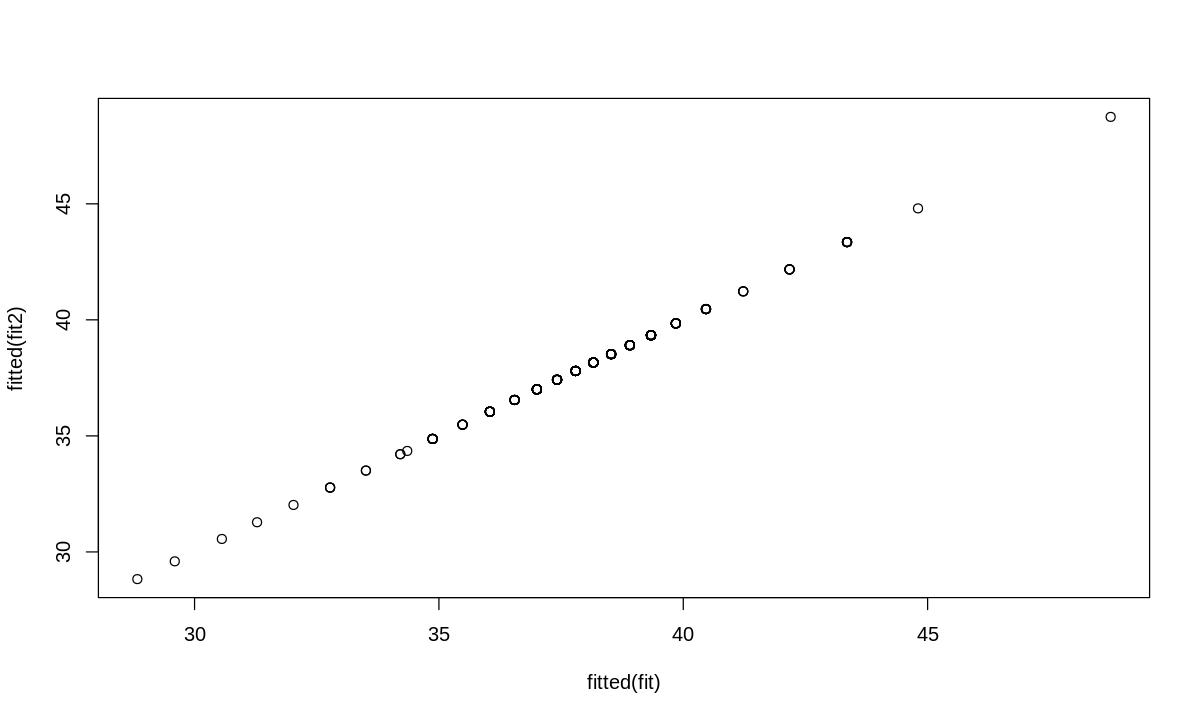

In [ ]:
plot(fitted(fit),fitted(fit2))

A grid of serum sodium values was created spanning the observed range in the data to generate smooth predictions from the fitted model. To determine the appropriate level of model complexity, polynomial regressions of increasing degree were compared using an `ANOVA` framework. This approach tests whether adding higher-order terms significantly improves model fit, and found that non linearity does not add statistical significance.


The coefficient summary of the fifth-degree polynomial confirms these results. Only the first term is statistically significant (p ≈ 0.0023), while all higher-order terms have large p-values. This provides the same conclusion as the ANOVA analysis, demonstrating that additional polynomial terms do not improve the model.

The p-values from the coefficient summary match those from ANOVA. In this case, the square of the t-statistic equals the F-statistic (e.g., $(0.575)^2 \approx 0.331$), confirming that both methods yield the same results.


######**Adding Non-linear Age Terms**

Furthermore, ANOVA results comparing linear, quadratic, and cubic `age` models show no significant improvement from adding higher-order terms (p = 0.7497 and p = 0.8459). Together with the `serum sodium `results, this demonstrates that key predictors in this dataset do not show strong nonlinear effects.

#####***Ejection Fraction: Classification***

To further analyze the relationship, the outcome is transformed into a binary variable indicating whether` ejection fraction` is below 30, representing a potentially clinically relevant threshold. Initially, a nonlinear logistic regression model is fitted using polynomial terms of `serum sodium` to allow for potential curvature in the relationship.


The nonlinear logistic model suggests an overall decreasing relationship between serum sodium and the probability of low `ejection fraction`. However, the fitted curve has irregular fluctuations and wide confidence bands, showing possible instability and high uncertainty. These patterns are consistent with earlier findings showing that higher-order terms are not statistically significant, and that the apparent nonlinearity could reflect overfitting.

Therefore, the same logistic regression model was fit for a simpler linear model. Once again, the linear logistic regression model shows a clear decreasing relationship between serum sodium and the probability of low `ejection fraction`.


#####***Step Functions***



The absence of statistically significant differences across intervals indicates that neither `serum sodium` nor `age` exhibits threshold effects. Grouping the data into discrete bins does not find meaningful variation in `ejection fraction`, meaning that the relationship may be continuous.

#####**Splines**




Regression splines can be fit by constructing an appropriate matrix of basis functions. A cubic regression spline was fit to model the relationship between `serum sodium` and `ejection fraction`. The spline allows for flexible, piecewise cubic behavior with smooth transitions at the knot locations. Here the prespecified knots at serum sodium levels were $134$, $137$, and $140$. This produces a spline with six basis functions.This is consistent with uniform quantiles of the data. While the fitted curve could mean slight nonlinearity, especially at higher sodium levels, the wide confidence intervals in these areas also show large uncertainty.

Next, a natural spline with 4 degrees of freedom was fit to model the relationship between `serum sodium `and `ejection fraction`. Compared to the cubic regression spline, the natural spline imposes linearity at the boundaries, leading to a smoother fit. Unlike the previous spline, no extreme behavior is observed at the boundaries, meaning that earlier spikes may have been due to overfitting.

A smoothing spline was fit to the data using two levels of flexibility. The curve with 16 degrees of freedom follows the data closely and shows sharp fluctuations, capturing local variation but also noise. The cross-validated spline (≈2 degrees of freedom) is much smoother, producing a gradual upward trend without abrupt changes. This stark difference is because the cross validation selected the smoothness level that gave the lowest prediction error. Once again, there seems to be no strong nonlinear pattern.

##### ***Local Regression***



Here local linear regression is performed using spans of $0.2$ and $0.5$: that is, each neighborhood consists of 20\,\% or 50\,\% of the observations. The larger the span, the smoother the fit. The loess curve with span = 0.2 follows the data more closely and shows several fluctuations, capturing local variation especially around 130-140. The curve with span = 0.5 is smoother and highlights the overall pattern, showing a gradual increase in ejection fraction as serum sodium rises. The 130-140 region is notably smoother, and the drop from 140-145 is also much reduced.

The sensitivity of the fit to the choice of span highlights the instability of highly flexible models and further supports the use of simpler specifications.

#####***GAMs***




The model is now fit using smoothing splines rather than natural splines.  Using the `gam` library, a smoothing spline is used and it is specified that the function of `serum_sodium` should have $4$ degrees of freedom, and that the function of `age` will have $5$ degrees of freedom. Since `sex` is qualitative, it is left as is. All of the terms are fit simultaneously, taking each other into account to explain the response.

The estimated effect of `serum sodium` shows mild curvature, with a small dip followed by an increase. However, the wide confidence bands and earlier model comparisons indicate that this nonlinearity is weak. The effect of `age` is mostly flat across mid-range values, with an increase at higher ages. The upward trend at older `ages` is accompanied by wide confidence bands, which could mean potentially greater uncertainty. Sex enters the model as a categorical variable, producing a constant difference in `ejection fraction` between the groups, with one group being associated with lower values.

A series of ANOVA tests is performed in order to determine which of these three models is best: a GAM that excludes `serum_sodium` ($\mathcal{M}_1$), a GAM that uses a linear function of `serum_sodium` ($\mathcal{M}_2$), or  a GAM that uses a spline function of `serum_sodium` ($\mathcal{M}_3$). The ANOVA results show that adding `serum sodium` as a predictor significantly improves the model compared to excluding it (p = $0.0023$). However, allowing for a nonlinear spline effect does not provide an improvement over the linear model(p = $0.3477$).

The model reduces deviance from 41738.91 to 38824.84, indicating a modest improvement in fit. Serum sodium contributes significantly (F = 3.09, p = 0.016), accounting for a portion of the explained variation (Sum Sq = 1669), while sex also has a strong effect (F = 7.27, p = 0.007, Sum Sq = 980). In contrast, age provides very minimal explanatory power (F = 0.39, p = 0.853, Sum Sq = 266). Combined with earlier ANOVA results, this supports including serum sodium as a predictor, but without a nonlinear spline, and shows that age may not improve the model.

When local regression was used for the `serum_sodium` term, with a span of $0.7$ the model shows a weak, slightly increasing pattern for `age`, a noisy and unstable loess fit for `serum sodium`, and a clear linear decrease for `sex`.

The `lo()` function can also be used to create interactions fits a two-term model, the first term is an interaction between `serum_sodium` and `age`, fit by a local regression surface, showing their joint effect on `ejection fraction`, which looks irregular and highly variable. On the other hand, `sex `once again shows a clear linear decrease.

This confirms that even in a multivariate setting, allowing nonlinear effects does not significantly improve model performance over linear terms

#####***Ejection Fraction: Classification GAMs***




In order to fit a logistic regression GAM, the `I()` function is used in constructing the binary response variable. Individuals in the group coded as 1(males) have a higher proportion of low ejection fraction (23.2%) compared to those coded as 0 (females) (13.3%), demonstrating a notable difference. While some individual values of age and serum sodium have no observations of low ejection fraction, these variables are treated as continuous predictors. Unlike categorical variables, there is no need to remove any values, and the full dataset can be used.

# 6. Conclusion

Overall, the results across all modeling approaches consistently show that increased model complexity does not improve the ability to explain variation in `ejection fraction`. Despite testing a range of `nonlinear` methods, including `linear regression`, `polynomial regression`, `step functions`, `regression and smoothing splines`, `local regression (LOESS)`, and `generalized additive models (GAMs)`, there was little results showing meaningful nonlinear structure, and more flexible models often introduced instability. On the other hand, simple linear models provided more stable, interpretable, and reliable results. These findings show that, for this dataset, the relationship between `key predictors` and `ejection fraction` is fundamentally linear, and that prioritizing simplicity leads to better and more practical modeling outcomes.

# 7. Appendix


## Tables

In [ ]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)

In [ ]:
install.packages("kableExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘svglite’




In [ ]:
library(knitr)

results <- data.frame(
  Method = c(
    "Linear Regression",
    "Polynomial Regression",
    "Logistic Regression (Classification)",
    "Step Function",
    "Regression Splines",
    "Smoothing Splines",
    "Local Regression (LOESS)",
    "GAM (Continuous)",
    "Classification GAM"
  ),

  Nonlinear = c(
    "No",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes"
  ),

  Key_Results = c(
    "Baseline model",
    "Serum Sodium: Only first term significant (p≈0.0023); higher-order not significant",
    "Nonlinear terms unstable; decreasing trend for nonlinear and linear",
    "No significant intervals (p=0.324, 0.839, 0.590; age: 0.648, 0.958, 0.082)",
    "Sensitive to knots; boundary instability",
    "df=16 overfits; Cross Validated spline (df≈2) smooth",
    "Span=0.2 fluctuates; span=0.5 smooth",
    "Serum sodium (p=0.016) & sex (p=0.007) significant; age not (p=0.853)",
    "Serum sodium linear; age weak nonlinear; sex difference (Male 23.2% vs Female 13.3%)"
  ),

  Interpretation = c(
    "Simple linear model is appropiate and statistically significant for serum sodium",
    "No meaningful nonlinearity",
    "Linear model preferred",
    "No threshold effects",
    "Unstable, depends on tuning",
    "Overfitting to noise vs smoothing tradeoff",
    "Smaller span overfits, larger span stable",
    "Linear structure sufficient",
    "Nonlinearity weak; classification highlights group differences"
  )
)

kable(results, caption = "Model Comparison Results")



Table: Model Comparison Results

|Method                               |Nonlinear |Key_Results                                                                          |Interpretation                                                                   |
|:------------------------------------|:---------|:------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------|
|Linear Regression                    |No        |Baseline model                                                                       |Simple linear model is appropiate and statistically significant for serum sodium |
|Polynomial Regression                |Yes       |Serum Sodium: Only first term significant (p≈0.0023); higher-order not significant   |No meaningful nonlinearity                                                       |
|Logistic Regression (Classification) |Yes       |Nonlinear terms unstable; decreasing tr

In [ ]:
par(mfrow = c(1,1))
options(repr.plot.width = 7, repr.plot.height = 6)

In [ ]:
lm_sodium1 <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure)
options(repr.plot.width = 5, repr.plot.height = 4)
lm_age1 <- lm(ejection_fraction ~ age, data = HeartFailure)
options(repr.plot.width = 5, repr.plot.height = 4)
lm_sex1 <- lm(ejection_fraction ~ sex, data = HeartFailure)
options(repr.plot.width = 5, repr.plot.height = 4)